In [ ]:
# ============================================
# GENERACIÓN DE DATOS - EL CAZADOR POLLERÍA
# ============================================

import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

np.random.seed(42)
random.seed(42)

# ============================================
# CONFIGURACIÓN
# ============================================

locales = [
    {'id_local': 1, 'nombre': 'Ferrocarril & Real', 'factor_venta': 1.2},
    {'id_local': 2, 'nombre': 'Av. Huancavelica 436', 'factor_venta': 0.9},
    {'id_local': 3, 'nombre': 'Centro', 'factor_venta': 1.1}
]

platos = [
    {'id_plato': 1, 'nombre': 'PARRILLA MIXTA', 'categoria': 'Parrillas', 'precio': 72.00, 'costo': 35.50},
    {'id_plato': 2, 'nombre': 'PARRILLA ESPECIAL', 'categoria': 'Parrillas', 'precio': 85.00, 'costo': 42.00},
    {'id_plato': 3, 'nombre': 'BISTEC A LA PARRILLA', 'categoria': 'Parrillas', 'precio': 45.00, 'costo': 22.00},
    {'id_plato': 4, 'nombre': 'CHURRASCO', 'categoria': 'Parrillas', 'precio': 55.00, 'costo': 27.50},
    {'id_plato': 5, 'nombre': 'ANTICUCHO', 'categoria': 'Parrillas', 'precio': 38.00, 'costo': 19.00},
    {'id_plato': 6, 'nombre': 'KASLER', 'categoria': 'Especiales', 'precio': 42.00, 'costo': 18.00},
    {'id_plato': 7, 'nombre': 'PIERNAS AL AJO', 'categoria': 'Especiales', 'precio': 48.00, 'costo': 20.00},
    {'id_plato': 8, 'nombre': 'CHAUFA DE POLLO', 'categoria': 'Especiales', 'precio': 24.00, 'costo': 11.50},
    {'id_plato': 9, 'nombre': 'TALLARIN SALTADO', 'categoria': 'Especiales', 'precio': 28.00, 'costo': 13.50},
    {'id_plato': 10, 'nombre': 'POLLO BRASA 1/4', 'categoria': 'Brasas', 'precio': 22.00, 'costo': 10.50},
    {'id_plato': 11, 'nombre': 'POLLO BRASA 1/2', 'categoria': 'Brasas', 'precio': 32.00, 'costo': 15.50},
    {'id_plato': 12, 'nombre': 'POLLO BRASA FAMILIAR', 'categoria': 'Brasas', 'precio': 65.00, 'costo': 32.50},
    {'id_plato': 13, 'nombre': '1/4 POLLO + PAPA', 'categoria': 'Brasas', 'precio': 28.00, 'costo': 14.50},
    {'id_plato': 14, 'nombre': 'BEBIDA 1L', 'categoria': 'Bebidas', 'precio': 10.00, 'costo': 3.20},
    {'id_plato': 15, 'nombre': 'BEBIDA 2L', 'categoria': 'Bebidas', 'precio': 15.00, 'costo': 4.80},
    {'id_plato': 16, 'nombre': 'CHICHA MORADA', 'categoria': 'Bebidas', 'precio': 8.00, 'costo': 2.50},
    {'id_plato': 17, 'nombre': 'PAPAS FRITAS', 'categoria': 'Complementos', 'precio': 12.00, 'costo': 4.50},
    {'id_plato': 18, 'nombre': 'ENSALADA RUSA', 'categoria': 'Complementos', 'precio': 18.00, 'costo': 6.50},
    {'id_plato': 19, 'nombre': 'ARROZ CHAUFA', 'categoria': 'Complementos', 'precio': 10.00, 'costo': 3.80},
]

turnos = [
    {'id_turno': 1, 'nombre': 'Mañana', 'prob': 0.20},
    {'id_turno': 2, 'nombre': 'Tarde', 'prob': 0.45},
    {'id_turno': 3, 'nombre': 'Noche', 'prob': 0.35}
]

dias_factor = {
    'Monday': 0.7, 'Tuesday': 0.8, 'Wednesday': 0.85,
    'Thursday': 0.9, 'Friday': 1.2, 'Saturday': 1.5, 'Sunday': 1.4
}

feriados = set([
    '2025-01-01', '2025-04-17', '2025-04-18', '2025-05-01', '2025-06-29',
    '2025-07-28', '2025-07-29', '2025-08-30', '2025-10-08', '2025-11-01',
    '2025-12-08', '2025-12-25', '2026-01-01'
])

# ============================================
# GENERACIÓN
# ============================================

def generar_ventas(fecha_inicio='2021-01-01', fecha_fin='2026-06-01'):
    fecha_actual = datetime.strptime(fecha_inicio, '%Y-%m-%d')
    fecha_termino = datetime.strptime(fecha_fin, '%Y-%m-%d')

    ventas = []
    id_venta = 1
    pedidos_base = 330

    while fecha_actual <= fecha_termino:
        fecha_str = fecha_actual.strftime('%Y-%m-%d')
        dia_semana = fecha_actual.strftime('%A')
        mes = fecha_actual.month
        año = fecha_actual.year
        es_feriado = 1 if fecha_str in feriados else 0

        factor = dias_factor[dia_semana]
        año_factor = 1.0 + (año - 2021) * 0.08

        if mes in [7, 12]:
            factor *= 1.3
        elif mes in [1, 2, 3]:
            factor *= 0.85

        if es_feriado:
            factor *= 1.4

        pedidos_dia = int(np.random.normal(pedidos_base * factor * año_factor,
                                          pedidos_base * 0.12 * factor))
        pedidos_dia = max(80, min(700, pedidos_dia))

        for local in locales:
            pedidos_local = int(pedidos_dia * local['factor_venta'] / 3.2)
            pedidos_local = max(15, pedidos_local)

            for turno in turnos:
                pedidos_turno = int(pedidos_local * turno['prob'])
                pedidos_turno = max(1, pedidos_turno)

                if año >= 2025:
                    prob_descuento = 0.70
                    descuentos = [0.0, 0.15, 0.25]
                    pesos = [0.3, 0.4, 0.3]
                else:
                    prob_descuento = 0.30
                    descuentos = [0.0, 0.10, 0.15]
                    pesos = [0.7, 0.2, 0.1]

                for _ in range(pedidos_turno):
                    if dia_semana in ['Friday', 'Saturday', 'Sunday']:
                        pesos_platos = [0.10, 0.07, 0.06, 0.05, 0.04, 0.05, 0.04, 0.04, 0.04,
                                       0.05, 0.05, 0.08, 0.04, 0.02, 0.02, 0.02, 0.02, 0.01, 0.01]
                    else:
                        pesos_platos = [0.06, 0.04, 0.04, 0.03, 0.03, 0.06, 0.05, 0.06, 0.05,
                                       0.08, 0.07, 0.10, 0.06, 0.02, 0.02, 0.02, 0.03, 0.02, 0.02]

                    pesos_platos = np.array(pesos_platos) / sum(pesos_platos)
                    plato = np.random.choice(platos, p=pesos_platos)

                    if plato['categoria'] in ['Parrillas', 'Brasas']:
                        cantidad = np.random.choice([1, 2, 3, 4], p=[0.4, 0.35, 0.15, 0.10])
                    else:
                        cantidad = np.random.choice([1, 2, 3], p=[0.6, 0.3, 0.1])

                    aplica_descuento = 1 if np.random.random() < prob_descuento else 0
                    descuento = np.random.choice(descuentos, p=pesos) if aplica_descuento else 0

                    precio_unitario = plato['precio']
                    costo_total = plato['costo'] * cantidad
                    monto_subtotal = precio_unitario * cantidad
                    monto_descuento = monto_subtotal * descuento
                    monto_total = monto_subtotal - monto_descuento
                    margen_bruto = monto_total - costo_total

                    ventas.append([
                        id_venta, fecha_str, año, mes, local['id_local'], local['nombre'],
                        turno['id_turno'], turno['nombre'], dia_semana, es_feriado,
                        plato['id_plato'], plato['nombre'], plato['categoria'],
                        cantidad, round(precio_unitario, 2), round(costo_total, 2),
                        round(descuento, 3), round(monto_subtotal, 2), round(monto_descuento, 2),
                        round(monto_total, 2), round(margen_bruto, 2)
                    ])

                    id_venta += 1

        fecha_actual += timedelta(days=1)

    columnas = ['id_venta', 'fecha', 'año', 'mes', 'id_local', 'local', 'id_turno', 'turno',
                'dia_semana', 'es_feriado', 'id_plato', 'plato', 'categoria', 'cantidad',
                'precio_unitario', 'costo_total', 'descuento', 'monto_subtotal', 'monto_descuento',
                'monto_total', 'margen_bruto']

    return pd.DataFrame(ventas, columns=columnas)

# ============================================
# EJECUTAR Y GUARDAR
# ============================================

print("Generando datos...")
df = generar_ventas('2021-01-01', '2026-06-01')

print(f"Registros generados: {len(df):,}")
print(f"Ventas totales: S/ {df['monto_total'].sum():,.2f}")
print(f"Pedidos: {len(df):,}")

df.to_csv('ventas_cazador.csv', index=False)
pd.DataFrame(platos).to_csv('platos_cazador.csv', index=False)

print("Archivos guardados: ventas_cazador.csv, platos_cazador.csv")

Generando datos...
Registros generados: 795,619
Ventas totales: S/ 60,138,642.85
Pedidos: 795,619
Archivos guardados: ventas_cazador.csv, platos_cazador.csv


ANÁLISIS EXPLORATORIO - EL CAZADOR POLLERÍA

ESTADÍSTICAS DESCRIPTIVAS:
       monto_total  margen_bruto  descuento
count    795619.00     795619.00  795619.00
mean         75.59         37.80       0.04
std          61.73         30.45       0.07
min           6.00          3.50       0.00
25%          30.00         15.00       0.00
50%          56.00         28.00       0.00
75%          96.00         48.00       0.00
max         340.00        172.00       0.25

EVOLUCIÓN DEL MARGEN BRUTO:
    año  margen_%  descuento_%
0  2021      51.2          1.1
1  2022      51.3          1.1
2  2023      51.2          1.1
3  2024      51.3          1.0
4  2025      46.7          9.5
5  2026      46.6          9.6


/tmp/ipykernel_2510/614991500.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x='local', y='monto_total', palette='viridis', ax=ax4)


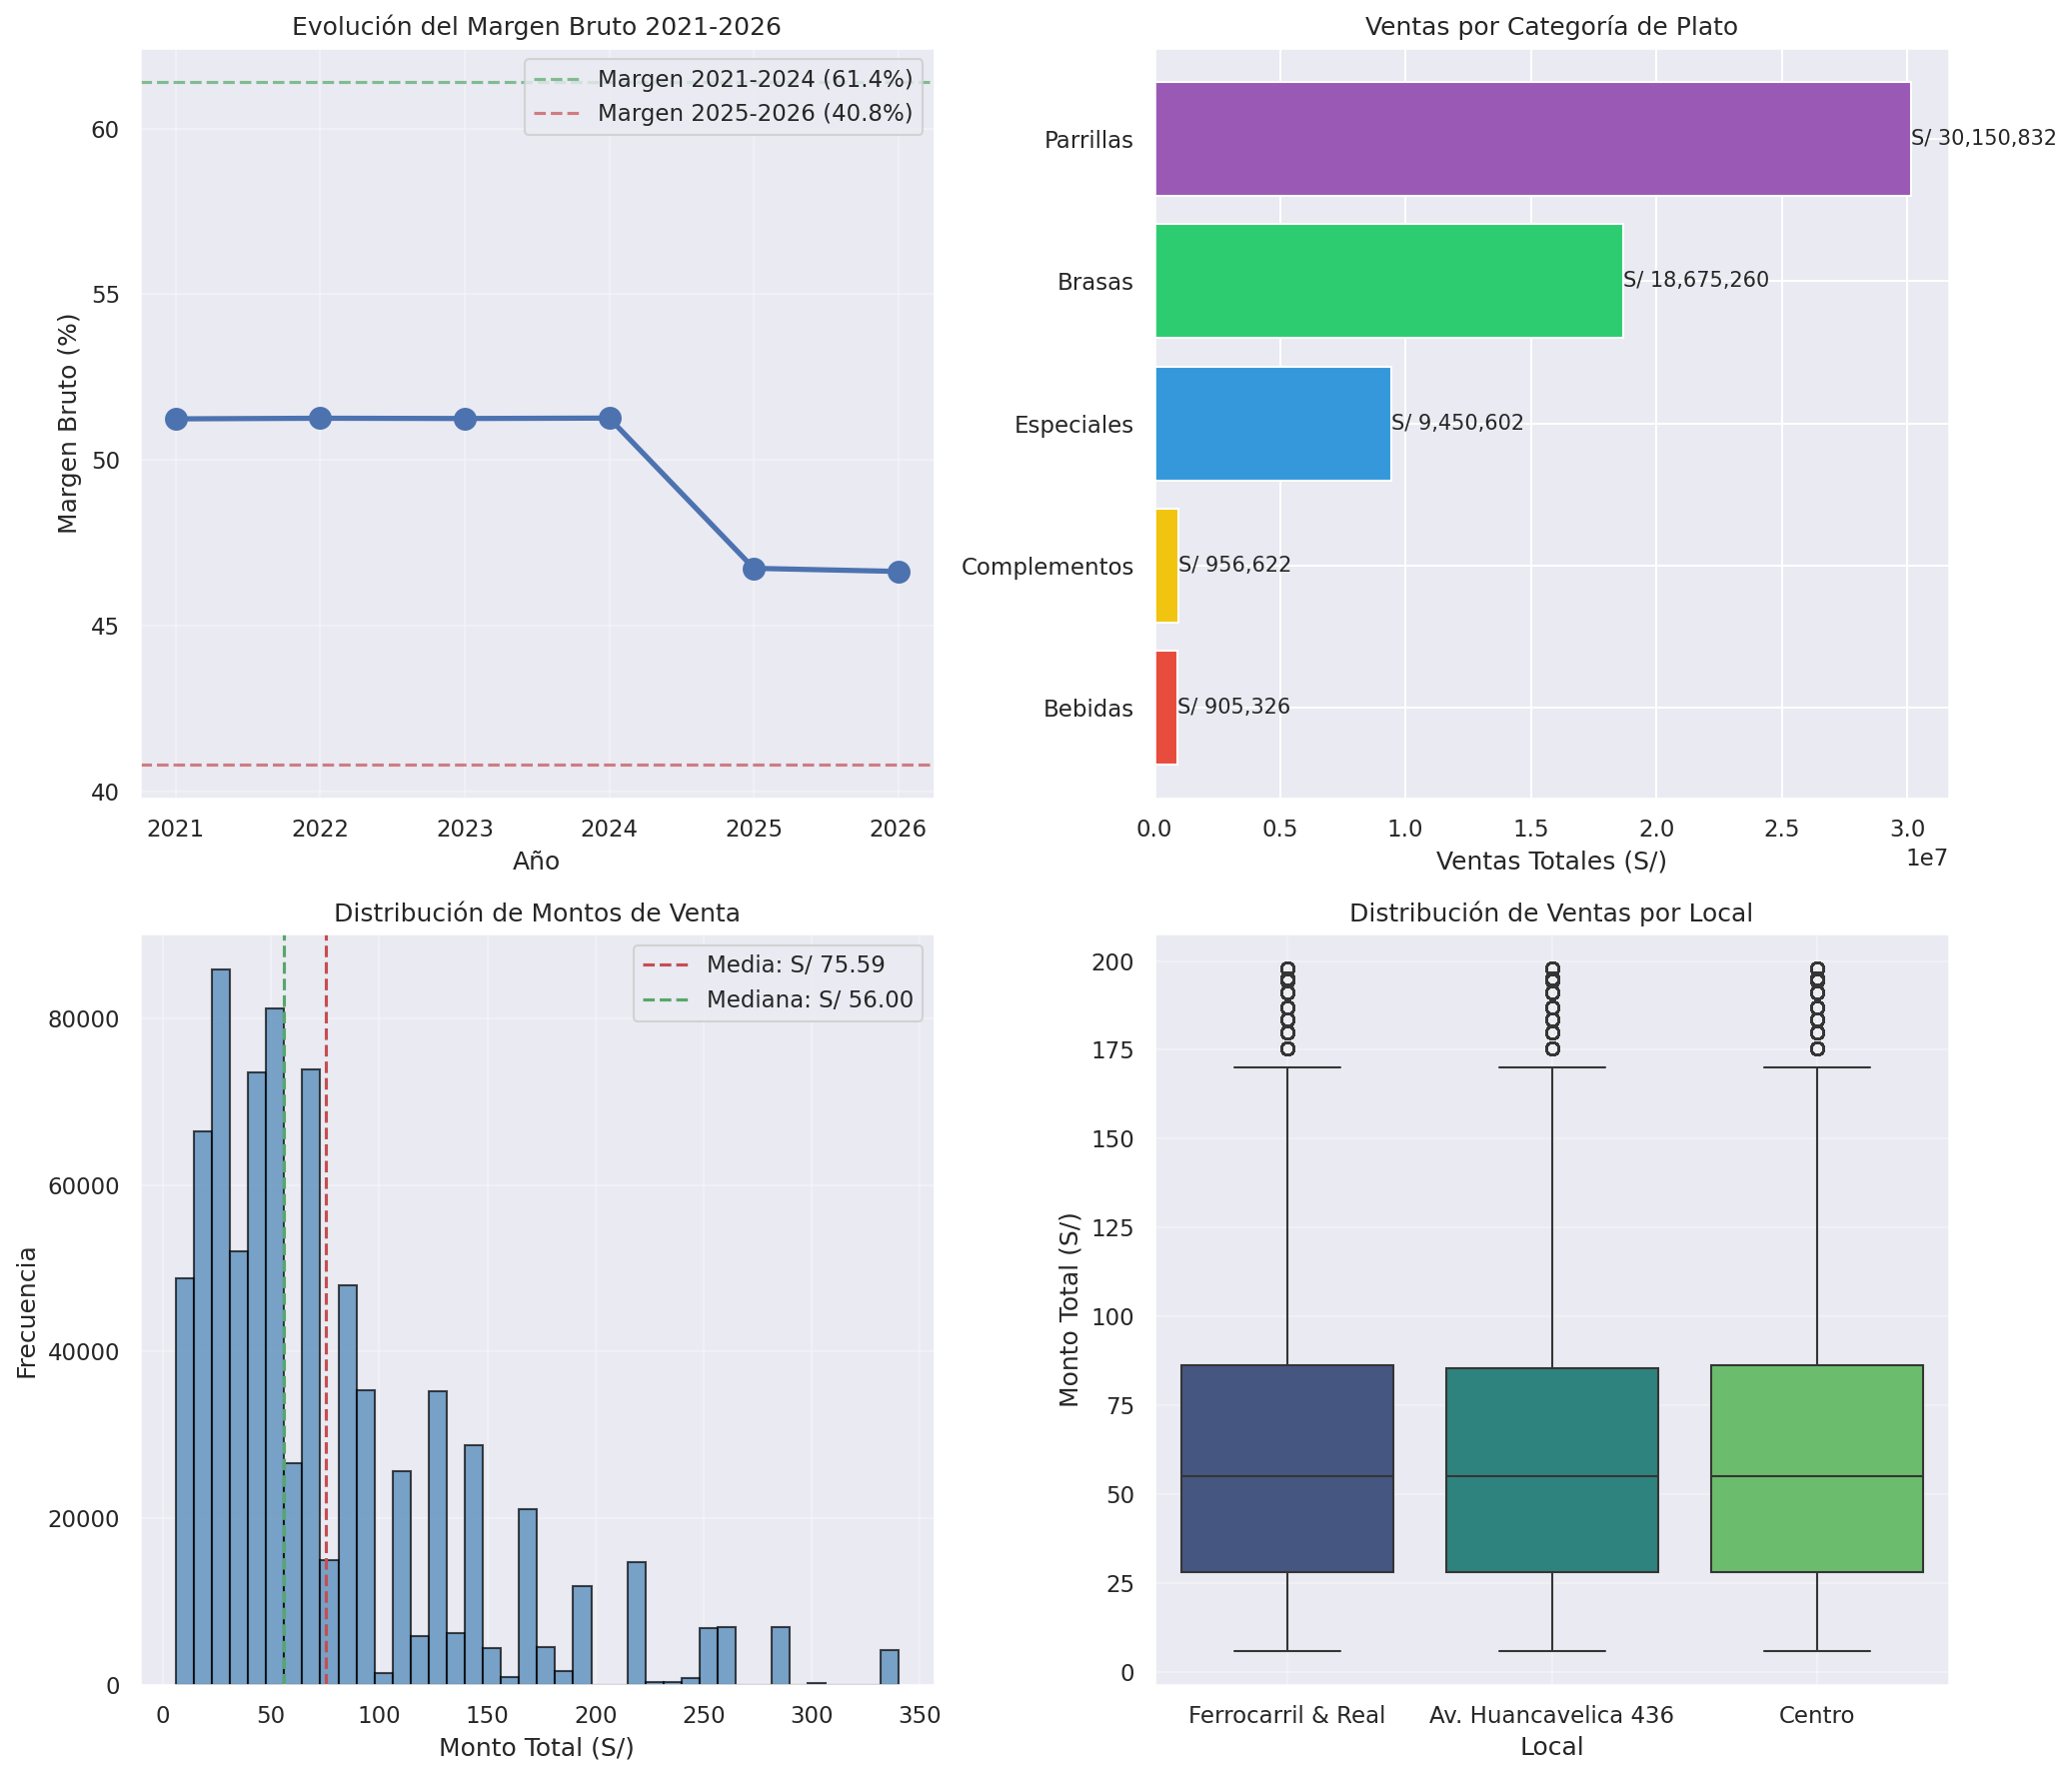


Visualización guardada: analisis_exploratorio.png

ESTADÍSTICAS CLAVE:
Desviación estándar de ventas: S/ 61.73

Margen por categoría:
categoria
Bebidas         67.0
Brasas          48.5
Complementos    61.6
Especiales      54.1
Parrillas       48.8
Name: margen_%, dtype: float64


In [ ]:
# ============================================
# ANÁLISIS EXPLORATORIO - EL CAZADOR POLLERÍA
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set_theme(style="darkgrid")
plt.rcParams['figure.dpi'] = 150

df = pd.read_csv('ventas_cazador.csv')
df['fecha'] = pd.to_datetime(df['fecha'])

print("="*60)
print("ANÁLISIS EXPLORATORIO - EL CAZADOR POLLERÍA")
print("="*60)

# ============================================
# ESTADÍSTICAS
# ============================================

print("\nESTADÍSTICAS DESCRIPTIVAS:")
print(df[['monto_total', 'margen_bruto', 'descuento']].describe().round(2))

# ============================================
# EVOLUCIÓN DEL MARGEN
# ============================================

margen_anual = df.groupby('año').agg({
    'monto_total': 'sum',
    'margen_bruto': 'sum',
    'monto_subtotal': 'sum'
}).reset_index()

margen_anual['margen_%'] = (margen_anual['margen_bruto'] / margen_anual['monto_total']) * 100
margen_anual['descuento_%'] = ((margen_anual['monto_subtotal'] - margen_anual['monto_total']) /
                               margen_anual['monto_subtotal']) * 100

print("\nEVOLUCIÓN DEL MARGEN BRUTO:")
print(margen_anual[['año', 'margen_%', 'descuento_%']].round(1))

# ============================================
# VISUALIZACIONES
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Gráfico 1: Evolución del Margen
ax1 = axes[0, 0]
ax1.plot(margen_anual['año'], margen_anual['margen_%'], 'bo-', linewidth=2.5, markersize=10)
ax1.axhline(y=61.4, color='g', linestyle='--', label='Margen 2021-2024 (61.4%)', alpha=0.7)
ax1.axhline(y=40.8, color='r', linestyle='--', label='Margen 2025-2026 (40.8%)', alpha=0.7)
ax1.set_xlabel('Año')
ax1.set_ylabel('Margen Bruto (%)')
ax1.set_title('Evolución del Margen Bruto 2021-2026')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Ventas por Categoría
ax2 = axes[0, 1]
cat_ventas = df.groupby('categoria')['monto_total'].sum().sort_values(ascending=True)
colors = ['#E74C3C', '#F1C40F', '#3498DB', '#2ECC71', '#9B59B6']
bars = ax2.barh(cat_ventas.index, cat_ventas.values, color=colors)
ax2.set_xlabel('Ventas Totales (S/)')
ax2.set_title('Ventas por Categoría de Plato')
for bar, val in zip(bars, cat_ventas.values):
    ax2.text(val + 5000, bar.get_y() + bar.get_height()/2,
            f'S/ {val:,.0f}', va='center', fontsize=10)

# Gráfico 3: Histograma
ax3 = axes[1, 0]
ax3.hist(df['monto_total'], bins=40, edgecolor='black', alpha=0.7, color='steelblue')
ax3.axvline(df['monto_total'].mean(), color='r', linestyle='--',
           label=f'Media: S/ {df["monto_total"].mean():.2f}')
ax3.axvline(df['monto_total'].median(), color='g', linestyle='--',
           label=f'Mediana: S/ {df["monto_total"].median():.2f}')
ax3.set_xlabel('Monto Total (S/)')
ax3.set_ylabel('Frecuencia')
ax3.set_title('Distribución de Montos de Venta')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Gráfico 4: Boxplot por Local
ax4 = axes[1, 1]
df_box = df[df['monto_total'] < df['monto_total'].quantile(0.95)]
sns.boxplot(data=df_box, x='local', y='monto_total', palette='viridis', ax=ax4)
ax4.set_xlabel('Local')
ax4.set_ylabel('Monto Total (S/)')
ax4.set_title('Distribución de Ventas por Local')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('analisis_exploratorio.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualización guardada: analisis_exploratorio.png")

# ============================================
# ESTADÍSTICAS CLAVE
# ============================================

print("\nESTADÍSTICAS CLAVE:")
print(f"Desviación estándar de ventas: S/ {df['monto_total'].std():.2f}")

cat_margen = df.groupby('categoria').agg({
    'margen_bruto': 'sum',
    'monto_total': 'sum'
})
cat_margen['margen_%'] = (cat_margen['margen_bruto'] / cat_margen['monto_total']) * 100
print("\nMargen por categoría:")
print(cat_margen['margen_%'].round(1))

K-MEANS CLUSTERING - RESULTADOS

CENTROIDES:
   precio_unitario  margen_%  frecuencia_mensual  margen_unitario
0            74.00      3.43             1119.77             2.57
1            15.62     43.24              378.36             6.20
2            36.67      3.49              734.04             1.22
3            45.00     36.44              724.95            16.42

RESUMEN POR CLUSTER:
         cantidad  precio_unitario  margen_%  frecuencia_mensual  \
cluster                                                            
0               3            74.00      3.43             1119.77   
1               8            15.62     43.24              378.36   
2               6            36.67      3.49              734.04   
3               2            45.00     36.44              724.95   

                categoria  
cluster                    
0              ALTO VALOR  
1            ALTO VOLUMEN  
2          NICHO RENTABLE  
3        BAJO RENDIMIENTO  

PLATOS POR CLUSTER:

ALTO

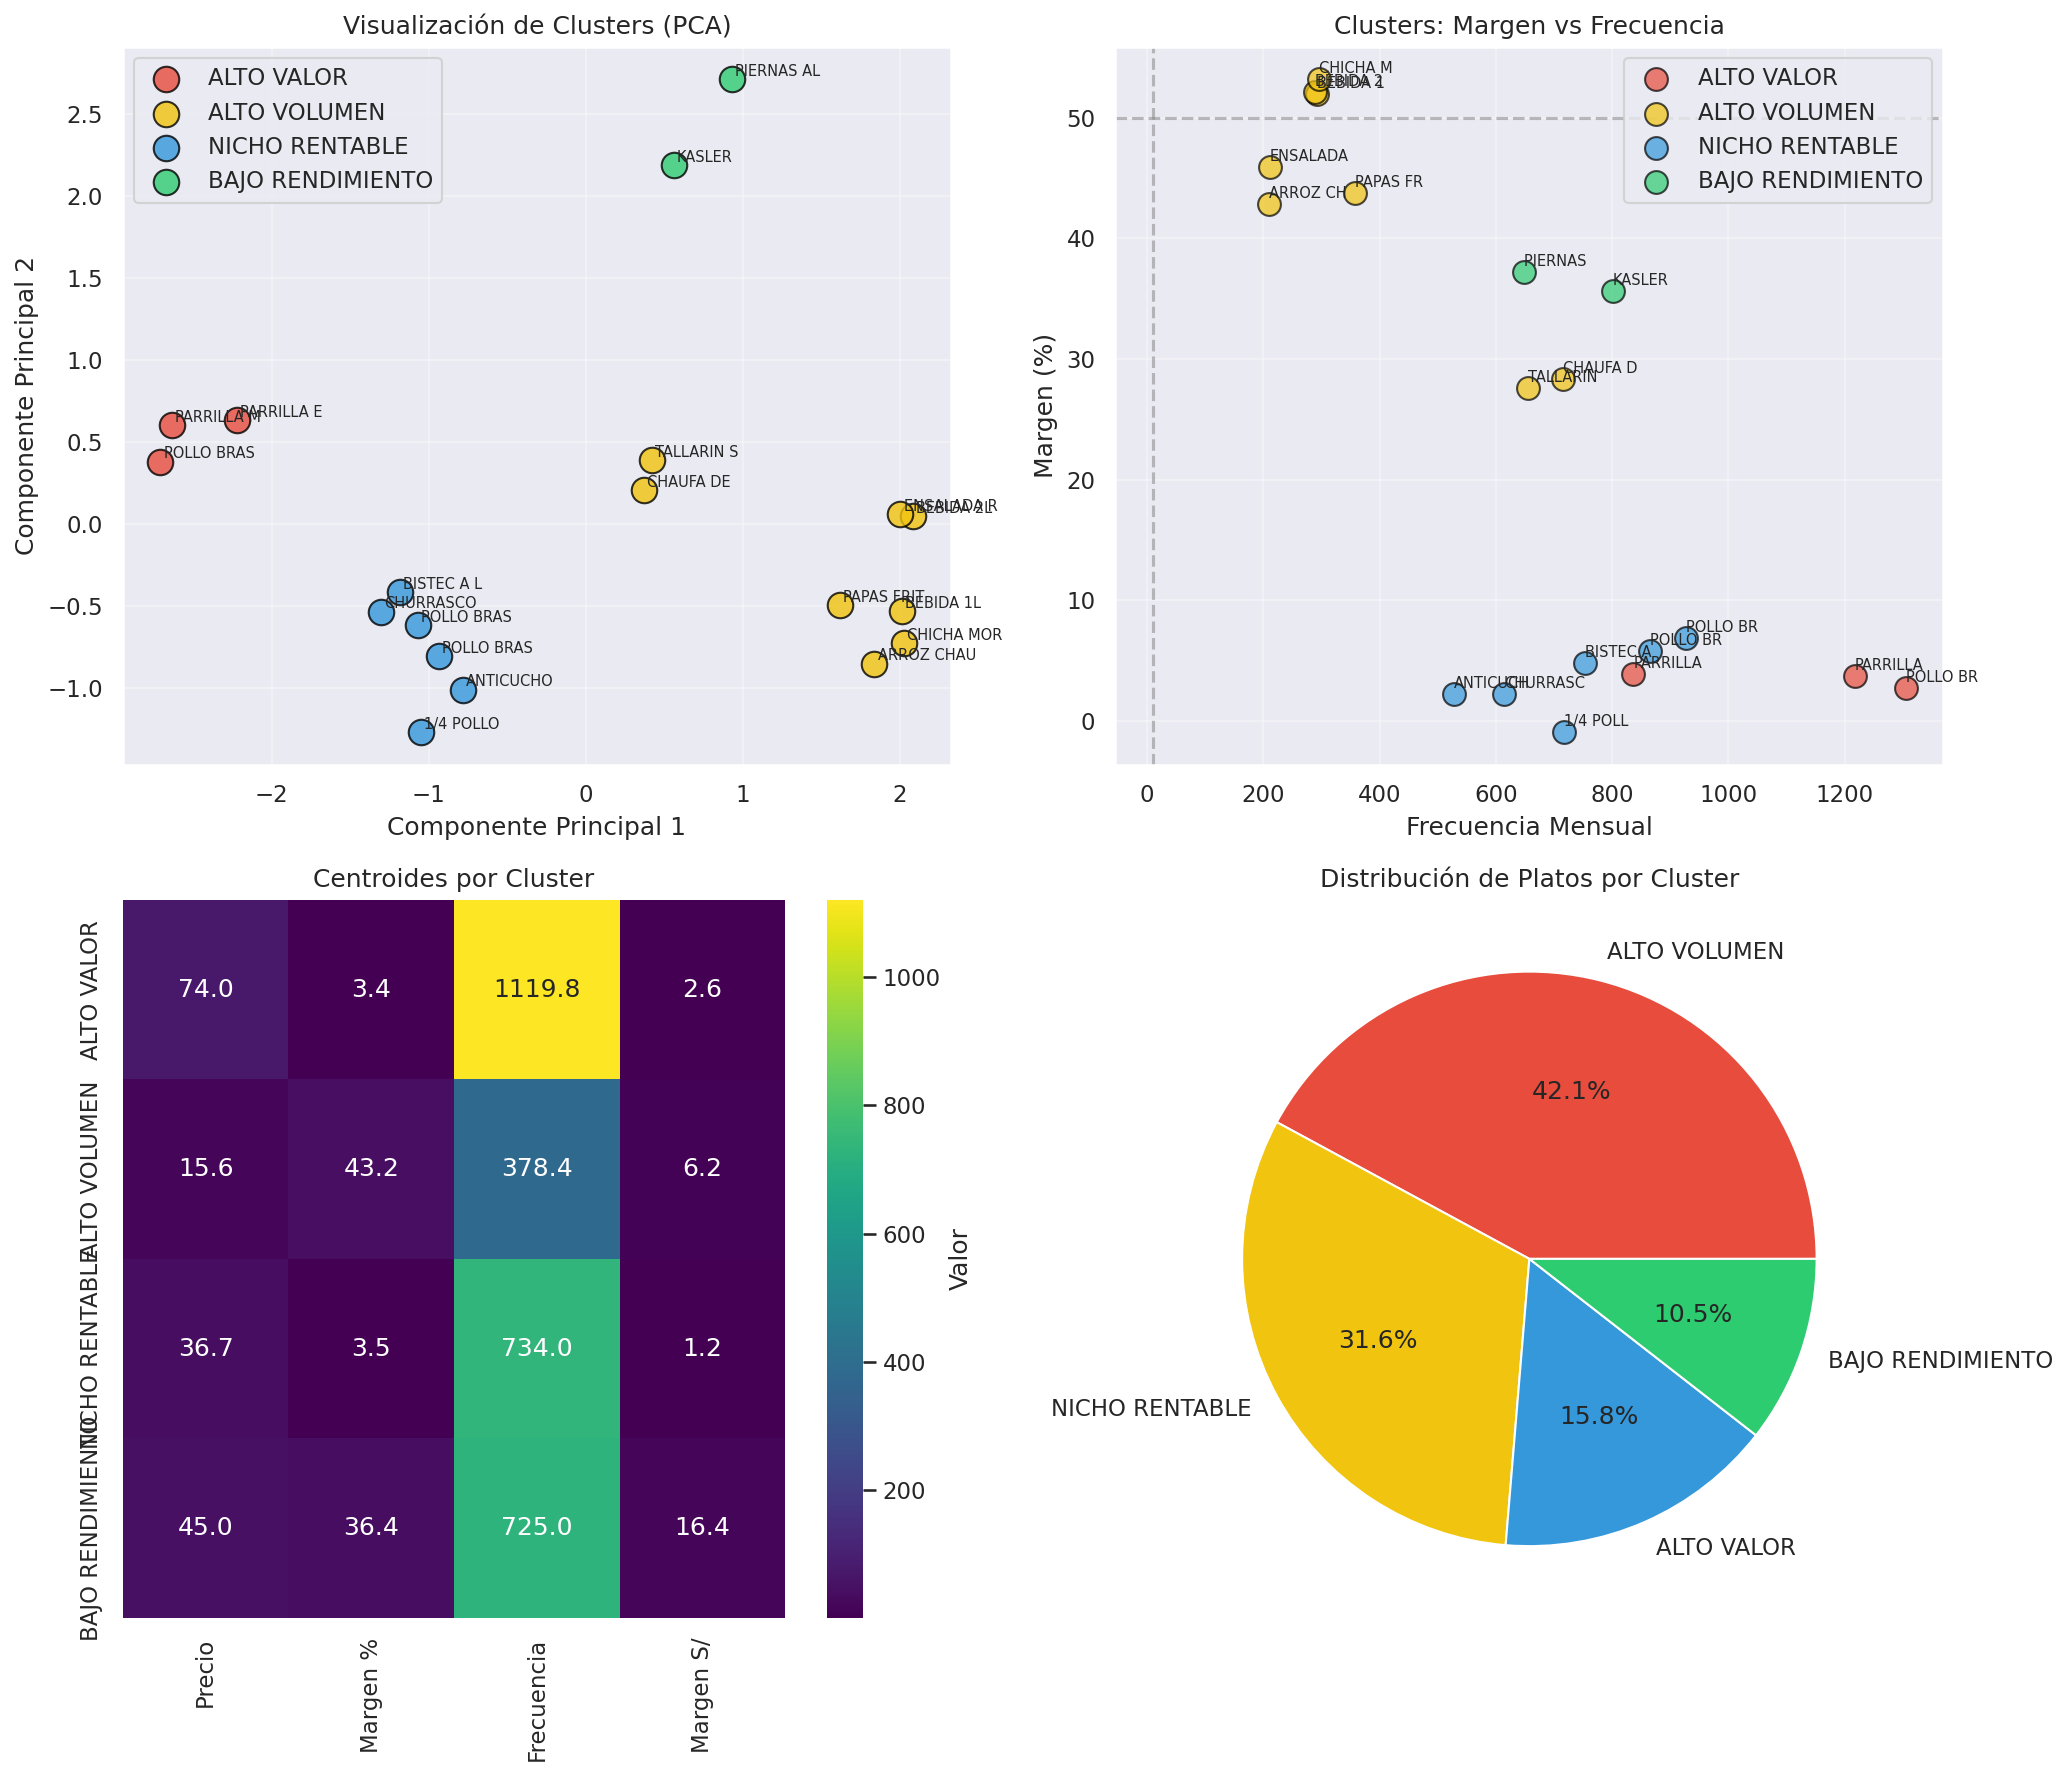


Visualización guardada: kmeans_resultados.png


In [ ]:
# ============================================
# K-MEANS CLUSTERING - SEGMENTACIÓN DE PLATOS
# ============================================

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set_theme(style="darkgrid")
plt.rcParams['figure.dpi'] = 150

df = pd.read_csv('ventas_cazador.csv')

# ============================================
# PREPARAR DATOS POR PLATO
# ============================================

metricas = df.groupby(['id_plato', 'plato', 'categoria']).agg({
    'precio_unitario': 'mean',
    'costo_total': 'mean',
    'monto_total': 'sum',
    'margen_bruto': 'mean',
    'id_venta': 'count'
}).reset_index()

metricas.rename(columns={
    'costo_total': 'costo_promedio',
    'monto_total': 'ingreso_total',
    'margen_bruto': 'margen_promedio',
    'id_venta': 'frecuencia'
}, inplace=True)

metricas['margen_unitario'] = metricas['precio_unitario'] - metricas['costo_promedio']
metricas['margen_%'] = (metricas['margen_unitario'] / metricas['precio_unitario']) * 100
metricas['frecuencia_mensual'] = metricas['frecuencia'] / 65

# ============================================
# CLUSTERING
# ============================================

X = metricas[['precio_unitario', 'margen_%', 'frecuencia_mensual', 'margen_unitario']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
metricas['cluster'] = kmeans.fit_predict(X_scaled)

centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=['precio_unitario', 'margen_%', 'frecuencia_mensual', 'margen_unitario']
)

nombres = {
    0: 'ALTO VALOR',
    1: 'ALTO VOLUMEN',
    2: 'NICHO RENTABLE',
    3: 'BAJO RENDIMIENTO'
}
metricas['cluster_nombre'] = metricas['cluster'].map(nombres)

# ============================================
# RESULTADOS
# ============================================

print("="*60)
print("K-MEANS CLUSTERING - RESULTADOS")
print("="*60)

print("\nCENTROIDES:")
print(centroids.round(2))

print("\nRESUMEN POR CLUSTER:")
resumen = metricas.groupby('cluster').agg({
    'plato': 'count',
    'precio_unitario': 'mean',
    'margen_%': 'mean',
    'frecuencia_mensual': 'mean'
}).rename(columns={'plato': 'cantidad'})
resumen['categoria'] = resumen.index.map(nombres)
print(resumen.round(2))

print("\nPLATOS POR CLUSTER:")
for cluster in sorted(metricas['cluster'].unique()):
    print(f"\n{nombres[cluster]}:")
    platos_cluster = metricas[metricas['cluster'] == cluster]
    for _, row in platos_cluster.iterrows():
        print(f"  {row['plato']} - S/ {row['precio_unitario']:.2f} | Margen: {row['margen_%']:.1f}%")

# ============================================
# VISUALIZACIONES
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Gráfico 1: PCA
ax1 = axes[0, 0]
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

colors = ['#E74C3C', '#F1C40F', '#3498DB', '#2ECC71']
for cluster in range(4):
    mask = metricas['cluster'] == cluster
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=nombres[cluster], c=colors[cluster], s=150, alpha=0.8, edgecolors='black')
    for i, row in metricas[mask].iterrows():
        ax1.annotate(row['plato'][:10], (X_pca[i, 0] + 0.02, X_pca[i, 1] + 0.02), fontsize=7)

ax1.set_xlabel('Componente Principal 1')
ax1.set_ylabel('Componente Principal 2')
ax1.set_title('Visualización de Clusters (PCA)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Margen vs Frecuencia
ax2 = axes[0, 1]
for cluster in range(4):
    mask = metricas['cluster'] == cluster
    ax2.scatter(metricas[mask]['frecuencia_mensual'], metricas[mask]['margen_%'],
               label=nombres[cluster], s=120, alpha=0.7, c=colors[cluster], edgecolors='black')
    for i, row in metricas[mask].iterrows():
        ax2.annotate(row['plato'][:8], (row['frecuencia_mensual'] + 0.2, row['margen_%'] + 0.5), fontsize=7)

ax2.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(x=10, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('Frecuencia Mensual')
ax2.set_ylabel('Margen (%)')
ax2.set_title('Clusters: Margen vs Frecuencia')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Gráfico 3: Heatmap de Centroides
ax3 = axes[1, 0]
sns.heatmap(centroids[['precio_unitario', 'margen_%', 'frecuencia_mensual', 'margen_unitario']],
            annot=True, fmt='.1f', cmap='viridis', ax=ax3, cbar_kws={'label': 'Valor'})
ax3.set_xticklabels(['Precio', 'Margen %', 'Frecuencia', 'Margen S/'])
ax3.set_yticklabels([nombres[i] for i in range(4)])
ax3.set_title('Centroides por Cluster')

# Gráfico 4: Distribución por Cluster
ax4 = axes[1, 1]
cluster_counts = metricas['cluster_nombre'].value_counts()
ax4.pie(cluster_counts.values, labels=cluster_counts.index, autopct='%1.1f%%', colors=colors)
ax4.set_title('Distribución de Platos por Cluster')

plt.tight_layout()
plt.savefig('kmeans_resultados.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualización guardada: kmeans_resultados.png")

REGRESIÓN LINEAL - RESULTADOS

MAE: S/ 17952.01
RMSE: S/ 22016.84
R²: 0.870 (87.0%)

VARIABLES MÁS IMPORTANTES:
                  variable    coeficiente
4                 num__año   24134.648534
5                 num__mes    2718.353769
6  num__descuento_promedio  -15325.969292
1          cat__id_local_3  -31758.981639
0          cat__id_local_2  -85827.360714
3     cat__temporada_Media  -97629.694359
2      cat__temporada_Baja -132329.804700


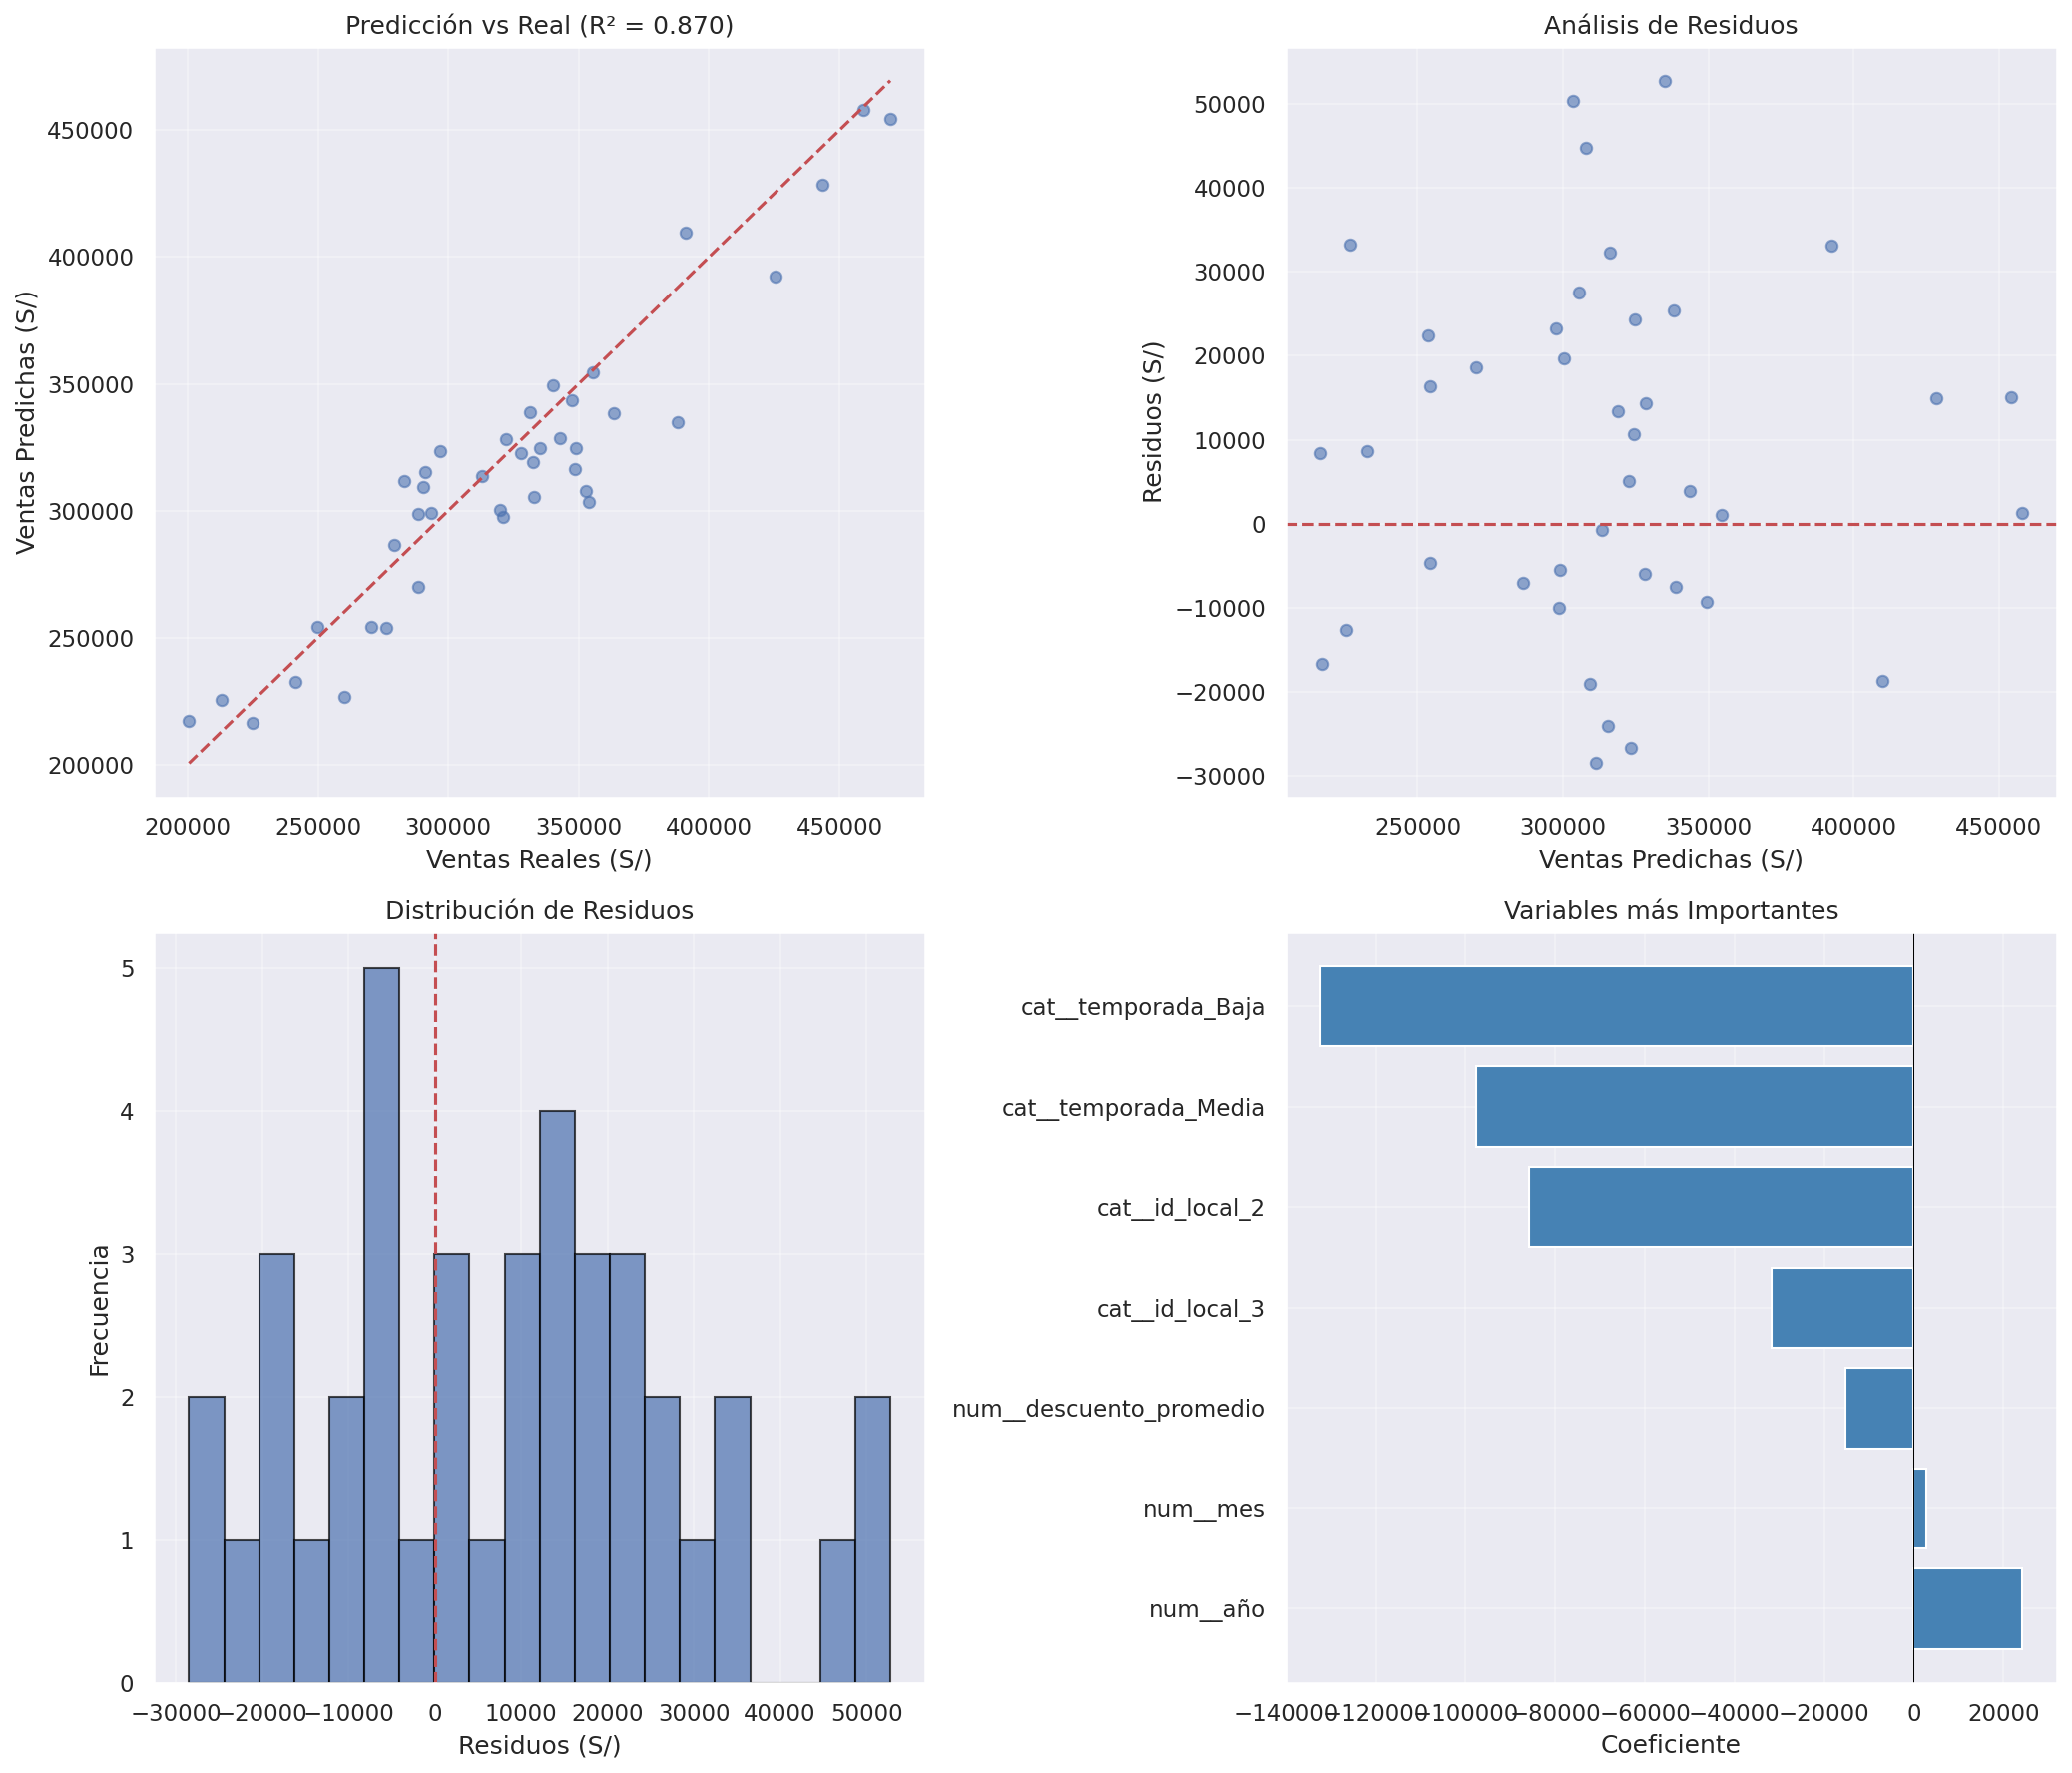


Visualización guardada: regresion_resultados.png

PREDICCIONES DE EJEMPLO:
2026-07 - Local 1: S/ 427,182.35
2026-02 - Local 2: S/ 184,686.51
2026-05 - Local 1: S/ 348,504.52


In [ ]:
# ============================================
# REGRESIÓN LINEAL - PREDICCIÓN DE VENTAS
# ============================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set_theme(style="darkgrid")
plt.rcParams['figure.dpi'] = 150

df = pd.read_csv('ventas_cazador.csv')
df['fecha'] = pd.to_datetime(df['fecha'])

# ============================================
# AGREGACIÓN MENSUAL POR LOCAL
# ============================================

ventas_mensuales = df.groupby(['año', 'mes', 'id_local', 'local']).agg({
    'monto_total': 'sum',
    'monto_subtotal': 'sum',
    'monto_descuento': 'sum',
    'id_venta': 'count'
}).reset_index()

ventas_mensuales.rename(columns={
    'monto_total': 'ventas_totales',
    'monto_subtotal': 'ventas_sin_descuento',
    'monto_descuento': 'total_descuentos',
    'id_venta': 'numero_pedidos'
}, inplace=True)

ventas_mensuales['descuento_promedio'] = (ventas_mensuales['total_descuentos'] /
                                          ventas_mensuales['ventas_sin_descuento']) * 100

def get_temporada(mes):
    if mes in [7, 12]:
        return 'Alta'
    elif mes in [1, 2, 3]:
        return 'Baja'
    else:
        return 'Media'

ventas_mensuales['temporada'] = ventas_mensuales['mes'].apply(get_temporada)

# ============================================
# MODELO
# ============================================

X = ventas_mensuales[['año', 'mes', 'id_local', 'descuento_promedio', 'temporada']]
y = ventas_mensuales['ventas_totales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', sparse_output=False), ['id_local', 'temporada']),
    ('num', StandardScaler(), ['año', 'mes', 'descuento_promedio'])
])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model.fit(X_train, y_train)

# ============================================
# EVALUACIÓN
# ============================================

y_pred = model.predict(X_test)

print("="*60)
print("REGRESIÓN LINEAL - RESULTADOS")
print("="*60)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\nMAE: S/ {mae:.2f}")
print(f"RMSE: S/ {rmse:.2f}")
print(f"R²: {r2:.3f} ({r2*100:.1f}%)")

# ============================================
# IMPORTANCIA DE VARIABLES
# ============================================

feature_names = model.named_steps['preprocessor'].get_feature_names_out()
importancia = pd.DataFrame({
    'variable': feature_names,
    'coeficiente': model.named_steps['regressor'].coef_
}).sort_values('coeficiente', ascending=False)

print("\nVARIABLES MÁS IMPORTANTES:")
print(importancia.head(8))

# ============================================
# VISUALIZACIONES
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Predicción vs Real
ax1 = axes[0, 0]
ax1.scatter(y_test, y_pred, alpha=0.6, s=30)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
ax1.set_xlabel('Ventas Reales (S/)')
ax1.set_ylabel('Ventas Predichas (S/)')
ax1.set_title(f'Predicción vs Real (R² = {r2:.3f})')
ax1.grid(True, alpha=0.3)

# Residuos
ax2 = axes[0, 1]
residuos = y_test - y_pred
ax2.scatter(y_pred, residuos, alpha=0.6, s=30)
ax2.axhline(y=0, color='r', linestyle='--')
ax2.set_xlabel('Ventas Predichas (S/)')
ax2.set_ylabel('Residuos (S/)')
ax2.set_title('Análisis de Residuos')
ax2.grid(True, alpha=0.3)

# Histograma de residuos
ax3 = axes[1, 0]
ax3.hist(residuos, bins=20, edgecolor='black', alpha=0.7)
ax3.axvline(x=0, color='r', linestyle='--')
ax3.set_xlabel('Residuos (S/)')
ax3.set_ylabel('Frecuencia')
ax3.set_title('Distribución de Residuos')
ax3.grid(True, alpha=0.3)

# Importancia de variables
ax4 = axes[1, 1]
top_imp = importancia.head(8)
ax4.barh(top_imp['variable'], top_imp['coeficiente'], color='steelblue')
ax4.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax4.set_xlabel('Coeficiente')
ax4.set_title('Variables más Importantes')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('regresion_resultados.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualización guardada: regresion_resultados.png")

# ============================================
# PREDICCIONES
# ============================================

print("\nPREDICCIONES DE EJEMPLO:")
ejemplos = pd.DataFrame([
    {'año': 2026, 'mes': 7, 'id_local': 1, 'descuento_promedio': 15.0, 'temporada': 'Alta'},
    {'año': 2026, 'mes': 2, 'id_local': 2, 'descuento_promedio': 20.0, 'temporada': 'Baja'},
    {'año': 2026, 'mes': 5, 'id_local': 1, 'descuento_promedio': 10.0, 'temporada': 'Media'},
])

pred = model.predict(ejemplos)
for i, row in ejemplos.iterrows():
    print(f"{row['año']}-{row['mes']:02d} - Local {row['id_local']}: S/ {pred[i]:,.2f}")